In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


In [2]:
# Number of simulations
n_samples = 1000

# Parameter bounds
a_low, a_high = 0.5, 2.0
b_low, b_high = 1.0, 3.0
noise_low, noise_high = 0.1, 0.5

# Random parameters
a = np.random.uniform(a_low, a_high, n_samples)
b = np.random.uniform(b_low, b_high, n_samples)
noise = np.random.uniform(noise_low, noise_high, n_samples)

# Input variable
x = np.random.uniform(0, 10, n_samples)

# Simulation model (non-linear system)
y = a * x + b * np.sin(x) + noise * np.random.randn(n_samples)

# Dataset
data = pd.DataFrame({
    "x": x,
    "a": a,
    "b": b,
    "noise": noise,
    "y": y
})

data.head()


,x,a,b,noise,y
0,1.940928,1.625407,2.310854,0.408088,5.153874
1,5.750631,1.080681,1.168596,0.341995,4.873245
2,4.183094,0.982516,2.182842,0.247155,2.330570
3,9.940911,1.778323,1.228447,0.203427,17.217309
4,2.308608,0.873038,2.068209,0.126545,3.330305


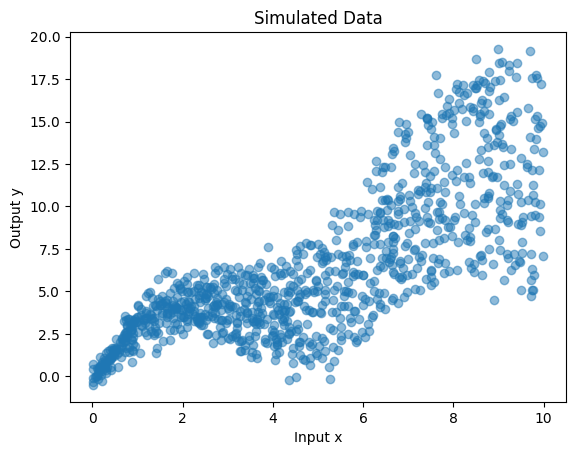

In [3]:
plt.scatter(x, y, alpha=0.5)
plt.xlabel("Input x")
plt.ylabel("Output y")
plt.title("Simulated Data")
plt.show()


In [4]:
X = data[["x", "a", "b", "noise"]]
y = data["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2 Score"])
results_df


,Model,MSE,R2 Score
0,Linear Regression,3.677306,0.798618
1,Decision Tree,0.484631,0.973460
2,Random Forest,0.212598,0.988357
3,SVR,0.448517,0.975438
4,KNN,0.389476,0.978671


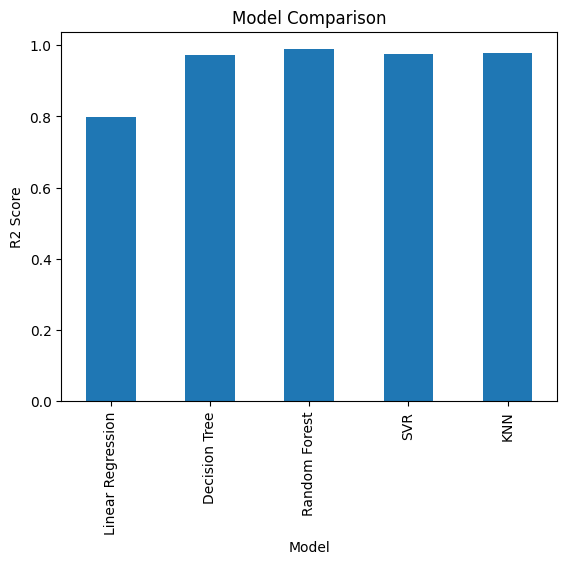

In [5]:
results_df.plot(x="Model", y="R2 Score", kind="bar", legend=False)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()
